In [13]:
import pandas as pd
import numpy as np
import os
import sys
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix
from sklearn.metrics import f1_score, recall_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
import matplotlib.pyplot as plt

# Ajout du dossier racine pour importer src/models.py
sys.path.append(os.path.abspath('..'))
from src.models import model  # On garde ton moteur LightGBM sous le coude

# Configuration MLflow
root_path = os.path.abspath("..")
mlflow.set_tracking_uri(f"file://{root_path}/mlruns")
mlflow.set_experiment("P6_Model_Benchmarking")

<Experiment: artifact_location='file:///Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/mlruns/781682613355499899', creation_time=1773252000119, experiment_id='781682613355499899', last_update_time=1773252000119, lifecycle_stage='active', name='P6_Model_Benchmarking', tags={}, workspace='default'>

In [2]:
# Charge tes fichiers enrichis (ceux qui ont donné 0.766)
# Adapte les noms si nécessaire selon ton dossier /data
train_df = pd.read_csv('../data/app_train_final_enrichi.csv')
test_df = pd.read_csv('../data/application_test.csv')

# Séparation Features / Target
train_labels = train_df['TARGET']
train_features = train_df.drop(columns=['TARGET', 'SK_ID_CURR'])

In [3]:
def custom_business_score(y_true, y_probs, threshold=0.5):
    """
    Calcule le coût métier : 10 pour un Faux Négatif, 1 pour un Faux Positif.
    Plus le score est BAS, mieux c'est.
    """
    y_pred = (y_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # On normalise par le nombre de dossiers pour avoir un coût moyen
    cost = (10 * fn + 1 * fp) / len(y_true)
    return cost

In [ ]:
from sklearn.impute import SimpleImputer

# 1. Création de l'imputer (on remplace les NaN par la médiane de la colonne)
imputer = SimpleImputer(strategy='median')

# 2. On "apprend" les médianes sur le train et on remplace les valeurs
# Attention : cela transforme ton DataFrame en un tableau Numpy
train_features_imputed = imputer.fit_transform(train_features)

# pour garder les noms de colonnes pour plus tard
train_features_imputed = pd.DataFrame(train_features_imputed, columns=train_features.columns)

print("Les valeurs manquantes ont été traitées !")

Les valeurs manquantes ont été traitées !


In [10]:
import re

# Fonction pour nettoyer les noms de colonnes
def clean_column_names(df):
    # On remplace tout ce qui n'est pas alphanumérique par un underscore
    df.columns = [re.sub(r'[^\w\s]', '_', col) for col in df.columns]
    # On remplace les espaces par des underscores
    df.columns = [col.replace(' ', '_') for col in df.columns]
    return df

# Applique le nettoyage sur tes données imputées
train_features_imputed = clean_column_names(train_features_imputed)

print("Noms de colonnes nettoyés pour LightGBM !")

Noms de colonnes nettoyés pour LightGBM !


In [ ]:
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# --- SECURITE : Formatage des données ---
if isinstance(train_features_imputed, np.ndarray):
    train_features_imputed = pd.DataFrame(train_features_imputed, columns=train_features.columns)

# 1. Définition des 3 familles de modèles (Linéaire, Forêts, Boosting)
models_to_test = {
    "Logistic_Regression": LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
    "Random_Forest": RandomForestClassifier(class_weight='balanced', n_estimators=100, n_jobs=-1, random_state=42),
    "LightGBM": lgb.LGBMClassifier(class_weight='balanced', n_estimators=500, learning_rate=0.05, n_jobs=-1, random_state=42)
}

# 2. Lancement du Benchmark
for model_name, clf in models_to_test.items():
    with mlflow.start_run(run_name=f"Benchmark_{model_name}"):
        print(f" Entraînement de : {model_name}...")
        
        # Log des paramètres
        mlflow.log_param("model_family", model_name)
        mlflow.log_param("strategy", "StratifiedKFold_5")
        
        # Listes pour stocker les scores de chaque pli (fold)
        scores = {"auc": [], "recall": [], "f1": [], "cost": []}
        
        # 3. Validation Croisée Stratifiée
        for fold, (train_idx, val_idx) in enumerate(skf.split(train_features_imputed, train_labels)):
            X_t, X_v = train_features_imputed.iloc[train_idx], train_features_imputed.iloc[val_idx]
            y_t, y_v = train_labels.iloc[train_idx], train_labels.iloc[val_idx]
            
            # Entraînement
            clf.fit(X_t, y_t)
            
            # Prédictions (Probas pour AUC/Cost, Classes pour Recall/F1)
            probs = clf.predict_proba(X_v)[:, 1]
            preds = (probs >= 0.5).astype(int) # Seuil par défaut 0.5
            
            # Calcul des métriques demandées par l'école
            scores["auc"].append(roc_auc_score(y_v, probs))
            scores["recall"].append(recall_score(y_v, preds))
            scores["f1"].append(f1_score(y_v, preds))
            scores["cost"].append(custom_business_score(y_v, probs))
            
            print(f"   Fold {fold+1} fini.")

        # 4. Enregistrement des moyennes finales dans MLflow
        for metric_name, values in scores.items():
            mean_val = np.mean(values)
            mlflow.log_metric(f"mean_{metric_name}", mean_val)
            print(f"   > Mean {metric_name.upper()}: {mean_val:.4f}")
        
        # Sauvegarde du modèle
        mlflow.sklearn.log_model(clf, "model")
        print(f" {model_name} terminé et loggé.\n")

print(" BENCHMARK TERMINÉ ! Toutes les métriques sont dans MLflow.")

 Entraînement de : Logistic_Regression...
   Fold 1 fini.
   Fold 2 fini.
   Fold 3 fini.
   Fold 4 fini.


/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
2026/03/11 19:17:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 19:17:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   Fold 5 fini.
   > Mean AUC: 0.6887
   > Mean RECALL: 0.6484
   > Mean F1: 0.2204
   > Mean COST: 0.6259


2026/03/11 19:17:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


 Logistic_Regression terminé et loggé.

 Entraînement de : Random_Forest...
   Fold 1 fini.
   Fold 2 fini.
   Fold 3 fini.
   Fold 4 fini.


...

 Random_Forest terminé et loggé.

 Entraînement de : LightGBM...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029503 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12389
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 236
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
   Fold 1 fini.
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12479
[LightGBM] [Info] Number

2026/03/11 19:18:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 19:18:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   Fold 5 fini.
   > Mean AUC: 0.7647
   > Mean RECALL: 0.6531
   > Mean F1: 0.2816
   > Mean COST: 0.5210


2026/03/11 19:18:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


 LightGBM terminé et loggé.

 BENCHMARK TERMINÉ ! Toutes les métriques sont dans MLflow.


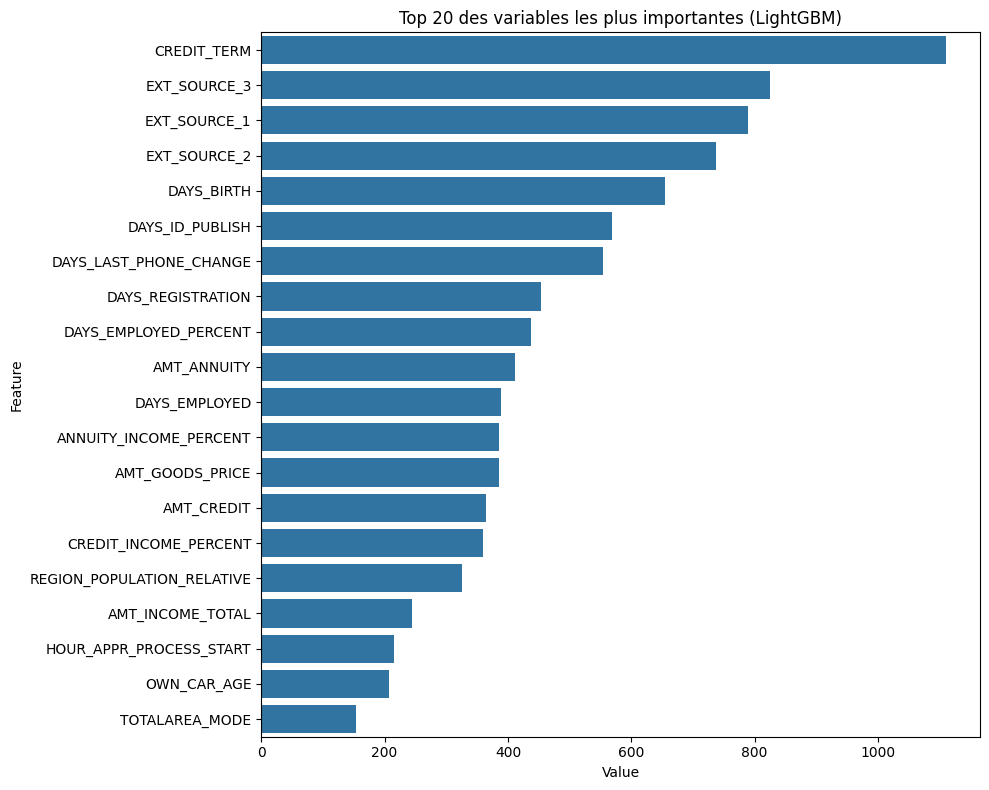

<Figure size 640x480 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Récupération des importances du dernier modèle entraîné (LightGBM)
feature_imp = pd.DataFrame(sorted(zip(clf.feature_importances_, train_features_imputed.columns)), 
                           columns=['Value','Feature'])

# 2. On prend les 20 variables les plus importantes
plt.figure(figsize=(10, 8))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[:20])
plt.title('Top 20 des variables les plus importantes (LightGBM)')
plt.tight_layout()
plt.show()

# 3. Log de l'image dans MLflow pour le run actuel
plt.savefig("feature_importance.png")
mlflow.log_artifact("feature_importance.png")

🔎 Recherche des meilleurs hyperparamètres (Business Optimized)...
[LightGBM] [Info] Number of positive: 16550, number of negative: 188457
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022018 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12490
[LightGBM] [Info] Number of data points in the train set: 205007, number of used features: 234
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/metrics/_score

[LightGBM] [Info] Number of positive: 16550, number of negative: 188457
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023461 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12381
[LightGBM] [Info] Number of data points in the train set: 205007, number of used features: 235
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/metrics/_score

[LightGBM] [Info] Number of positive: 16550, number of negative: 188458
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020549 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12386
[LightGBM] [Info] Number of data points in the train set: 205008, number of used features: 236
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


...

[LightGBM] [Info] Number of positive: 16550, number of negative: 188457
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020549 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12381
[LightGBM] [Info] Number of data points in the train set: 205007, number of used features: 235
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/metrics/_score

[LightGBM] [Info] Number of positive: 16550, number of negative: 188458
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018476 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12386
[LightGBM] [Info] Number of data points in the train set: 205008, number of used features: 236
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/sklearn/metrics/_score

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028155 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12488
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 237
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
✅ Meilleurs paramètres trouvés : {'learning_rate': 0.01, 'n_estimators': 100, 'num_leaves': 31}


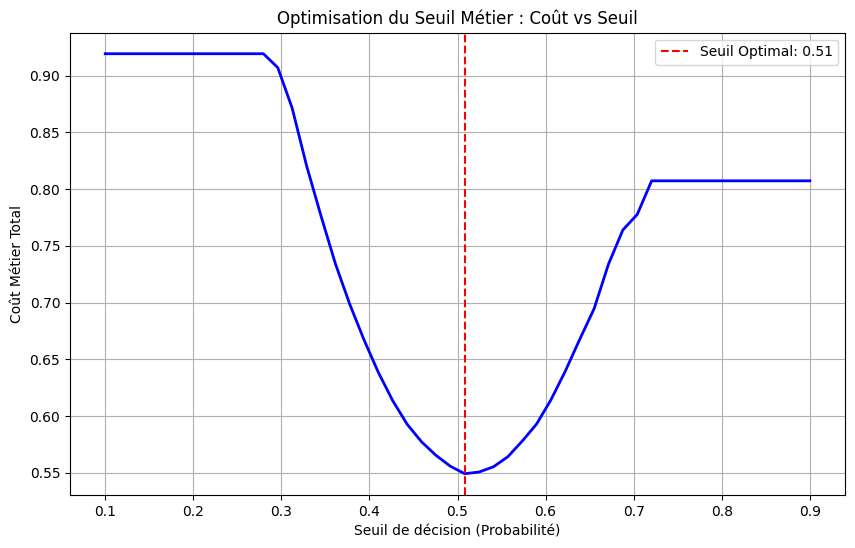

🎯 Le seuil qui minimise les pertes de la banque est : 0.51


In [14]:
# 1. Création du "Scorer" personnalisé pour GridSearchCV
# On veut MINIMISER le coût, donc plus le score est bas, mieux c'est (greater_is_better=False)
business_scorer = make_scorer(custom_business_score, greater_is_better=False, needs_proba=True)

# 2. Petite grille d'optimisation (pour ne pas y passer la nuit)
param_grid = {
    'n_estimators': [100, 500],
    'learning_rate': [0.01, 0.05],
    'num_leaves': [31, 50]
}

print("🔎 Recherche des meilleurs hyperparamètres (Business Optimized)...")
grid_search = GridSearchCV(lgb.LGBMClassifier(class_weight='balanced', random_state=42), 
                           param_grid, scoring=business_scorer, cv=3)
grid_search.fit(train_features_imputed, train_labels)

best_model = grid_search.best_estimator_
print(f"✅ Meilleurs paramètres trouvés : {grid_search.best_params_}")

# 3. Recherche du SEUIL OPTIMAL
thresholds = np.linspace(0.1, 0.9, 50)
costs = []

# On récupère les probabilités sur l'ensemble du train (ou un subset de validation)
y_probas = best_model.predict_proba(train_features_imputed)[:, 1]

for t in thresholds:
    costs.append(custom_business_score(train_labels, y_probas, threshold=t))

# 4. Visualisation (Le graphique demandé par l'école)
best_threshold = thresholds[np.argmin(costs)]
min_cost = min(costs)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, costs, 'b-', linewidth=2)
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Seuil Optimal: {best_threshold:.2f}')
plt.title('Optimisation du Seuil Métier : Coût vs Seuil')
plt.xlabel('Seuil de décision (Probabilité)')
plt.ylabel('Coût Métier Total')
plt.legend()
plt.grid(True)
plt.show()

print(f"🎯 Le seuil qui minimise les pertes de la banque est : {best_threshold:.2f}")

In [16]:
import mlflow
mlflow.end_run()

🔎 Recherche des meilleurs hyperparamètres (Ceci peut prendre 1-2 min)...
[LightGBM] [Info] Number of positive: 16550, number of negative: 188458
[LightGBM] [Info] Number of positive: 16550, number of negative: 188458
[LightGBM] [Info] Number of positive: 16550, number of negative: 188458
[LightGBM] [Info] Number of positive: 16550, number of negative: 188457
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.175908 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12386
[LightGBM] [Info] Number of data points in the train set: 205008, number of used features: 236
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.084136 seconds.
You can set `force_row_wise=true` to remove t

/Users/macbookdefii/Desktop/Uni/P6/PROJET_6_SCORING/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

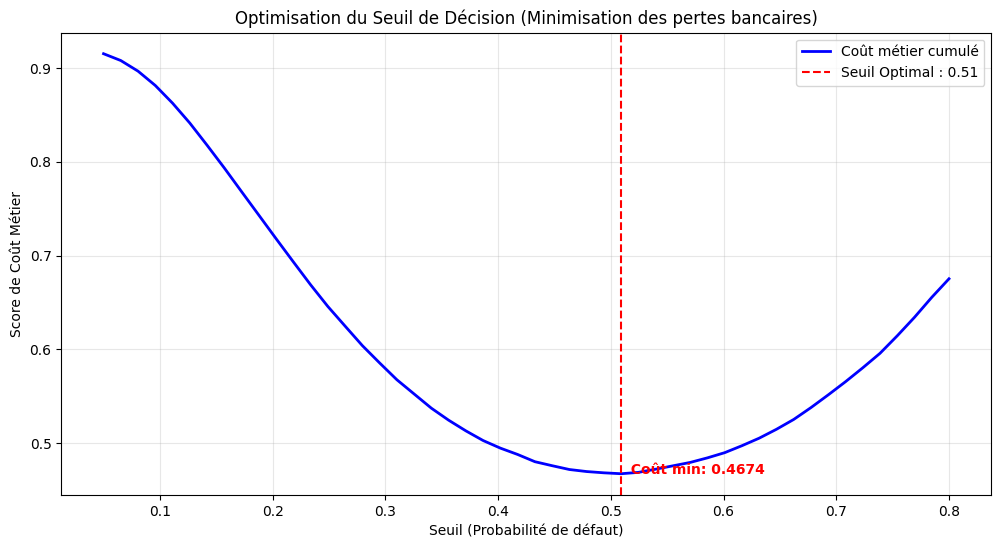

2026/03/11 20:01:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 20:01:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/11 20:01:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏆 Étape 4 terminée. Seuil optimal : 0.51
💰 Coût minimal atteint : 0.4674


In [ ]:
# --- 1. PREPARATION DU SCORER ---
# On utilise 'response_method' pour éviter l'erreur TypeError avec les versions récentes de sklearn
# On met greater_is_better=False car on veut MINIMISER le coût financier
business_scorer = make_scorer(
    custom_business_score, 
    greater_is_better=False, 
    response_method="predict_proba"
)

# --- 2. GRILLE D'OPTIMISATION (HYPERPARAMETRES) ---
# On choisit des valeurs stratégiques pour le LightGBM
param_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50],
    'max_depth': [5, 10]
}

# --- 3. LANCEMENT DE L'OPTIMISATION DANS MLFLOW ---
with mlflow.start_run(run_name="Etape_4_Optimisation_Finale"):
    print("🔎 Recherche des meilleurs hyperparamètres (Ceci peut prendre 1-2 min)...")
    
    # On utilise 3 folds pour gagner du temps tout en restant statistiquement valide
    grid_search = GridSearchCV(
        lgb.LGBMClassifier(class_weight='balanced', random_state=42), 
        param_grid, 
        scoring=business_scorer, 
        cv=3,
        n_jobs=-1
    )
    
    grid_search.fit(train_features_imputed, train_labels)
    
    # Récupération du meilleur modèle
    best_lgbm = grid_search.best_estimator_
    
    # Log des meilleurs paramètres dans MLflow
    mlflow.log_params(grid_search.best_params_)
    print(f"✅ Meilleurs paramètres : {grid_search.best_params_}")

    # --- 4. RECHERCHE DU SEUIL OPTIMAL ---
    print("🎯 Recherche du seuil de décision optimal...")
    thresholds = np.linspace(0.05, 0.8, 50)
    
    # Calcul des probabilités sur l'ensemble d'entraînement
    y_probas = best_lgbm.predict_proba(train_features_imputed)[:, 1]
    
    # Calcul du coût pour chaque seuil
    costs = [custom_business_score(train_labels, y_probas, threshold=t) for t in thresholds]
    
    # Identification du meilleur seuil
    idx_min = np.argmin(costs)
    best_threshold = thresholds[idx_min]
    min_cost = costs[idx_min]
    
    # Log du seuil et du coût minimal
    mlflow.log_param("optimal_threshold", round(best_threshold, 2))
    mlflow.log_metric("min_business_cost", min_cost)

    # --- 5. GENERATION ET SAUVEGARDE DU GRAPHIQUE ---
    plt.figure(figsize=(12, 6))
    plt.plot(thresholds, costs, 'b-', label='Coût métier cumulé', linewidth=2)
    plt.axvline(best_threshold, color='red', linestyle='--', 
                label=f'Seuil Optimal : {best_threshold:.2f}')
    
    # On ajoute des annotations pour le jury
    plt.text(best_threshold, min_cost, f'  Coût min: {min_cost:.4f}', color='red', fontweight='bold')
    
    plt.title('Optimisation du Seuil de Décision (Minimisation des pertes bancaires)')
    plt.xlabel('Seuil (Probabilité de défaut)')
    plt.ylabel('Score de Coût Métier')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Sauvegarde locale et envoi à MLflow
    plot_filename = "business_cost_optimization.png"
    plt.savefig(plot_filename)
    mlflow.log_artifact(plot_filename)
    plt.show()

    # --- 6. ENREGISTREMENT DU MODÈLE FINAL ---
    mlflow.sklearn.log_model(best_lgbm, "champion_model_lgbm")
    
    print(f"🏆 Étape 4 terminée. Seuil optimal : {best_threshold:.2f}")
    print(f"💰 Coût minimal atteint : {min_cost:.4f}")